# Q4-2：预测驱动的期末储能价值

运行环境：`mcm`。本 Notebook 调用独立实验模块，不复制模型实现。所有缓存与分析结果保存在 `.tmp/q4_terminal_value/`，不覆盖提交文件。

奖励输入是未来价格与供需曲线特征，输出是两端边际价值，再转换为凹二次奖励系数。直接估值对照使用同样预测信息，不看真实未来。

In [1]:
from pathlib import Path
import os, sys
sys.dont_write_bytecode = True
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'q4/terminal_value/core.py').exists())
sys.path.insert(0, str(ROOT/'q4/terminal_value'))
from experiment import run
from core import TMP
import pandas as pd
import json
from IPython.display import display, Image, Markdown
print('运行环境：', sys.executable)

运行环境： /Users/jinyu/miniconda3/envs/mcm/bin/python


## 完整实验

首次运行生成358天价值标签、完成56组选参、9种策略的冻结评价与全年探索，并生成中文报告。重复运行会校验并复用缓存。1—4月训练，5—8月选参；9—12月冻结价值模型。实际执行统一采用富余先充电、缺口先放电。

In [2]:
RUN_FULL_EXPERIMENT = False  # 首次复现时改为 True；已有结果直接展示
if RUN_FULL_EXPERIMENT:
    run('all')
else:
    assert (TMP/'frozen_summary.csv').exists(), '请将 RUN_FULL_EXPERIMENT 改为 True 后运行'

## 开发期选择与冻结评价

主模型只由开发期费用确定。以下评价期的最低费用策略仅为事后描述，不能用于重新选主模型。

In [3]:
selection = json.loads((TMP/'selection.json').read_text())
print('开发期预先选定主模型：', selection['primary'])
display(pd.DataFrame(selection['selected']).T)
display(pd.read_csv(TMP/'frozen_summary.csv'))

开发期预先选定主模型： quadratic_pca


,kind,feature,components,alpha
linear_economic,linear,economic,0,100.0
linear_pca,linear,pca,5,1.0
linear_hybrid,linear,hybrid,3,100.0
quadratic_economic,quadratic,economic,0,100.0
quadratic_pca,quadratic,pca,5,10.0
quadratic_hybrid,quadratic,hybrid,5,100.0


,strategy,phase,days,cash_cost,planned_cost,emergency_cost,emergency_kwh,initial_storage,end_storage,inventory_adjusted_045,...,max_balance_error,max_recursion_error,max_plan_balance_error,max_plan_recursion_error,value_fit_seconds,value_predict_seconds,teacher_seconds,mean_value_rmse_yuan,saving_yuan,saving_percent
0,fixed,frozen,122,5.546523e+06,5.439120e+06,107402.613074,17618.149228,6000.0,5923.522879,5.546557e+06,...,1.136868e-13,9.094947e-13,2.273737e-13,2.501110e-12,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
1,linear_economic,frozen,122,5.538458e+06,5.431492e+06,106965.542133,17350.746865,6000.0,9565.255794,5.536854e+06,...,1.136868e-13,9.094947e-13,2.273737e-13,2.501110e-12,0.000567,0.000147,0.000000,54.709777,8064.787531,0.145403
2,linear_pca,frozen,122,5.540918e+06,5.433953e+06,106965.542133,17350.746865,6000.0,10322.992773,5.538973e+06,...,1.136868e-13,9.094947e-13,2.273737e-13,2.501110e-12,0.005740,0.000272,0.000000,71.154386,5604.530256,0.101046
3,linear_hybrid,frozen,122,5.538597e+06,5.431631e+06,106965.542133,17350.746865,6000.0,9565.255794,5.536992e+06,...,1.136868e-13,9.094947e-13,2.273737e-13,2.501110e-12,0.005961,0.000295,0.000000,54.644991,7926.104508,0.142902
4,quadratic_economic,frozen,122,5.537287e+06,5.430516e+06,106771.063333,17317.126154,6000.0,9565.255797,5.535682e+06,...,1.136868e-13,9.094947e-13,1.357778e-10,7.559978e-10,0.000594,0.000175,0.000000,50.904921,9236.143023,0.166521
5,quadratic_pca,frozen,122,5.537658e+06,5.430887e+06,106771.063100,17317.126120,6000.0,9565.255802,5.536054e+06,...,1.136868e-13,9.094947e-13,1.420319e-10,2.789664e-08,0.005786,0.000324,0.000000,72.348074,8864.732643,0.159825
6,quadratic_hybrid,frozen,122,5.537432e+06,5.430661e+06,106771.063252,17317.126142,6000.0,9565.255797,5.535828e+06,...,1.136868e-13,9.094947e-13,1.374442e-10,9.508272e-11,0.005916,0.000334,0.000000,50.298885,9090.480233,0.163895
7,direct_quadratic,frozen,122,5.537185e+06,5.429745e+06,107439.665941,17602.781793,6000.0,8535.386908,5.536044e+06,...,1.136868e-13,9.094947e-13,1.340701e-10,1.185839e-09,0.000000,0.000000,2.071613,3.508686,9337.913266,0.168356
8,direct_pwl,frozen,122,5.537188e+06,5.429704e+06,107484.335838,17612.707633,6000.0,7797.111980,5.536380e+06,...,1.136868e-13,9.094947e-13,2.273737e-13,2.501110e-12,0.000000,0.000000,2.071613,0.000000,9334.331713,0.168292


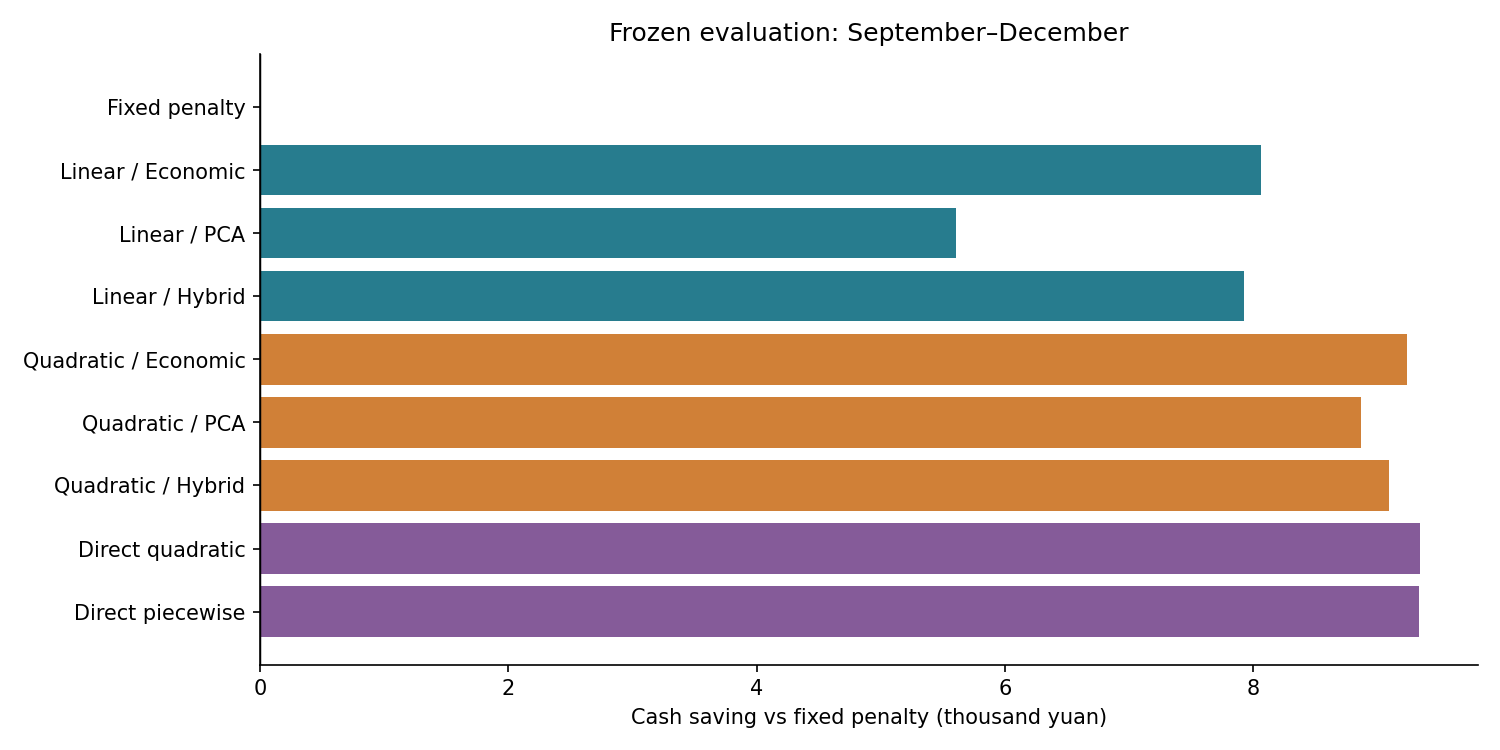

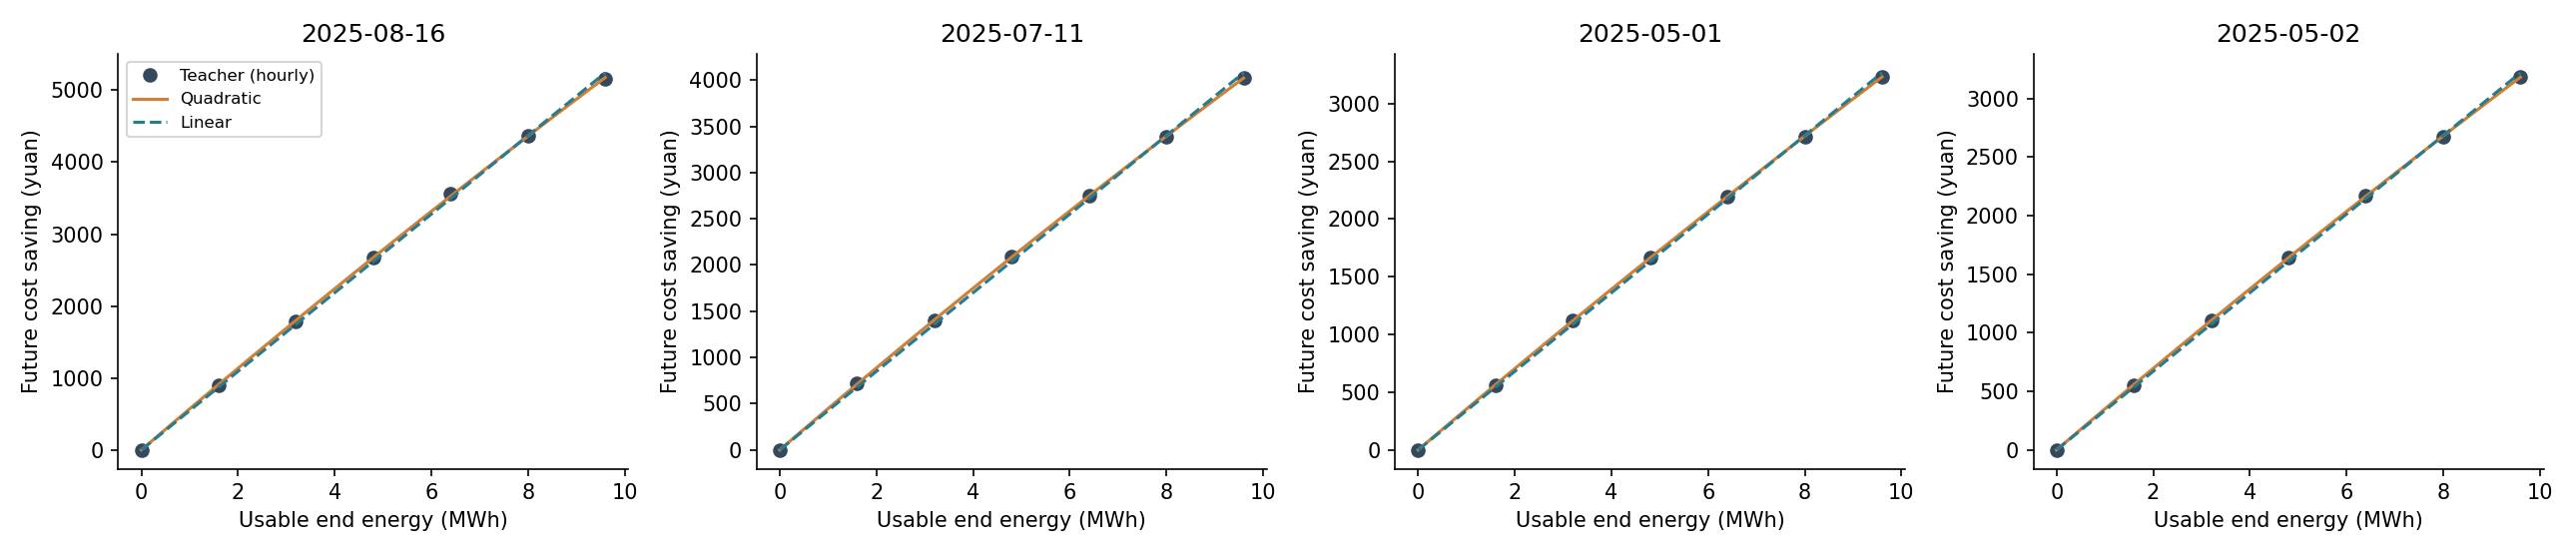

In [4]:
display(Image(filename=str(TMP/'figures/01_frozen_savings.png')))
display(Image(filename=str(TMP/'figures/02_value_curves.png')))

## 库存、执行偏差与老师敏感性

奖励和软惩罚不计入实际购电费用。库存估值只是会计敏感性，不是售电收入。

,strategy,cash_cost,inventory_adjusted_045,inventory_adjusted_090,mean_abs_terminal_gap,fallbacks
0,fixed,5.546523e+06,5.546557e+06,5.546592e+06,789.703576,0
1,linear_economic,5.538458e+06,5.536854e+06,5.535249e+06,690.868099,0
2,linear_pca,5.540918e+06,5.538973e+06,5.537028e+06,661.079144,0
3,linear_hybrid,5.538597e+06,5.536992e+06,5.535388e+06,690.830622,0
4,quadratic_economic,5.537287e+06,5.535682e+06,5.534078e+06,721.117978,0
5,quadratic_pca,5.537658e+06,5.536054e+06,5.534449e+06,713.842470,0
6,quadratic_hybrid,5.537432e+06,5.535828e+06,5.534224e+06,721.368335,0
7,direct_quadratic,5.537185e+06,5.536044e+06,5.534903e+06,722.194424,0
8,direct_pwl,5.537188e+06,5.536380e+06,5.535571e+06,717.921263,0


,date,variant,max_value_change_yuan,value_fit_rmse_yuan,a,b,low_marginal,high_marginal,linear_fit_rmse
0,2025-08-16,hourly_terminal6000,0.000000,17.133113,0.574992,0.000007,0.574992,0.503532,45.620964
1,2025-08-16,10min_terminal6000,176.486545,2.311026,0.543040,0.000004,0.543040,0.502157,24.299866
2,2025-08-16,hourly_terminal4800,0.000000,17.133113,0.574992,0.000007,0.574992,0.503532,45.620964
3,2025-08-16,hourly_terminal7200,0.000000,17.133113,0.574992,0.000007,0.574992,0.503532,45.620964
4,2025-07-11,hourly_terminal6000,0.000000,3.464924,0.449923,0.000006,0.449923,0.387921,36.848694
5,2025-07-11,10min_terminal6000,70.596985,7.165470,0.461336,0.000007,0.461336,0.390042,42.787621
6,2025-07-11,hourly_terminal4800,0.000000,3.464924,0.449923,0.000006,0.449923,0.387921,36.848694
7,2025-07-11,hourly_terminal7200,0.000000,3.464924,0.449923,0.000006,0.449923,0.387921,36.848694
8,2025-05-01,hourly_terminal6000,0.000000,2.126552,0.356197,0.000004,0.356197,0.316890,23.354023
9,2025-05-01,10min_terminal6000,137.129256,1.029576,0.343196,0.000004,0.343196,0.301831,24.496348


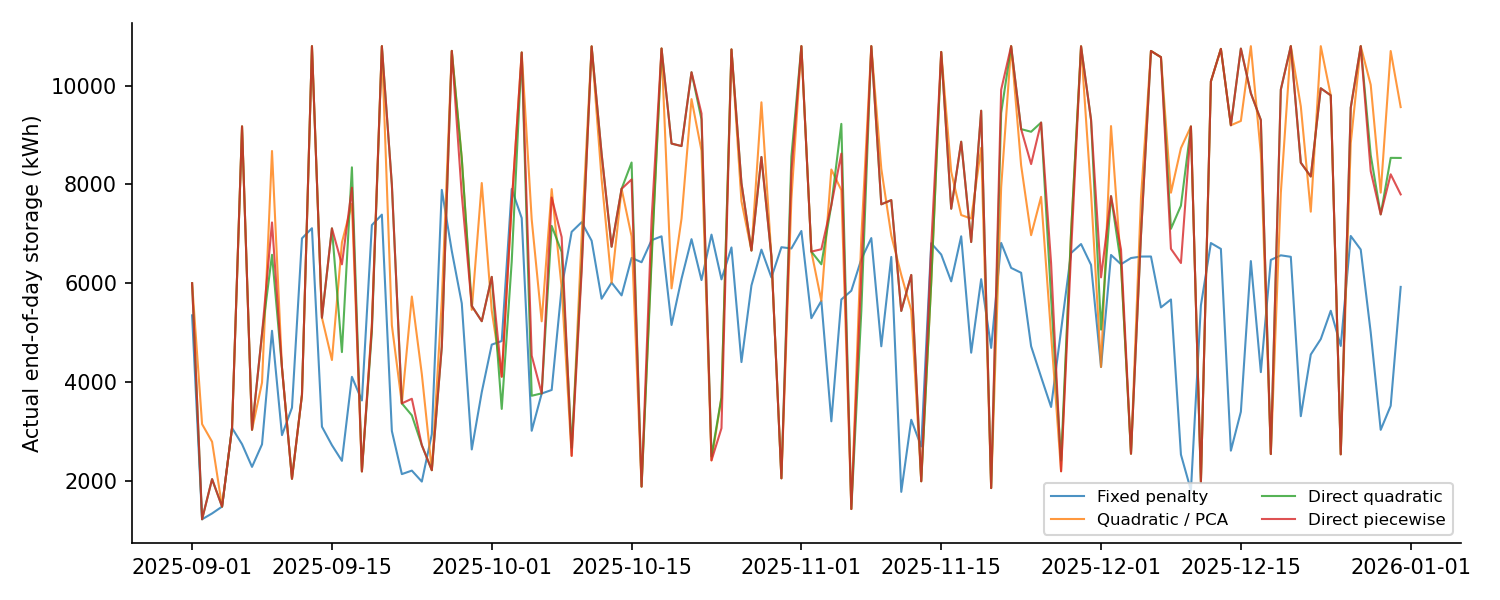

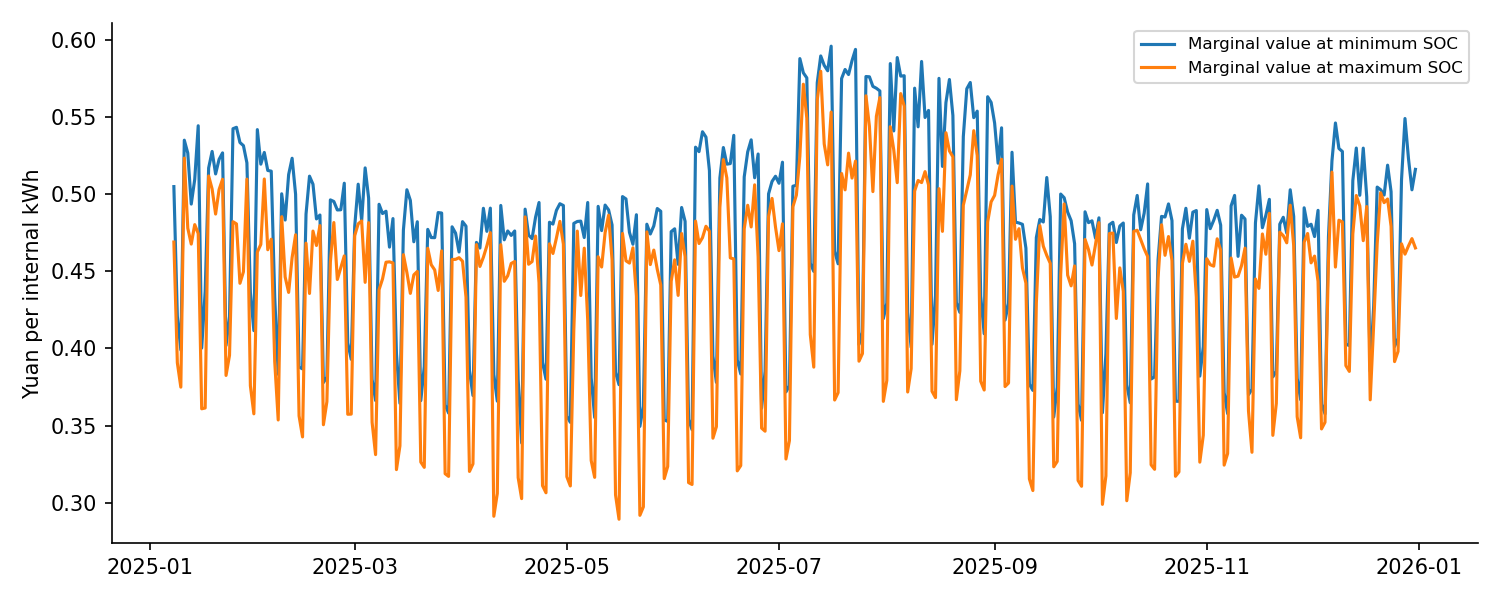

In [5]:
display(pd.read_csv(TMP/'frozen_summary.csv')[['strategy','cash_cost','inventory_adjusted_045','inventory_adjusted_090','mean_abs_terminal_gap','fallbacks']])
display(pd.read_csv(TMP/'teacher_sensitivity.csv'))
display(Image(filename=str(TMP/'figures/03_actual_end_storage.png')))
display(Image(filename=str(TMP/'figures/04_marginal_labels.png')))

## 全年探索性结果

全年使用开发期选出的超参数并按月重训，仅作探索，不是独立全年样本外证据。

In [6]:
display(pd.read_csv(TMP/'exploratory_summary.csv'))
display(json.loads((TMP/'run_metadata.json').read_text()))

,strategy,phase,days,cash_cost,planned_cost,emergency_cost,emergency_kwh,initial_storage,end_storage,inventory_adjusted_045,...,max_balance_error,max_recursion_error,max_plan_balance_error,max_plan_recursion_error,value_fit_seconds,value_predict_seconds,teacher_seconds,mean_value_rmse_yuan,saving_yuan,saving_percent
0,fixed,exploratory,334,1.440975e+07,1.409517e+07,314587.517622,49304.117219,6000.0,5923.522879,1.440979e+07,...,1.136868e-13,9.094947e-13,2.273737e-13,2.501110e-12,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
1,linear_economic,exploratory,334,1.439411e+07,1.407987e+07,314243.553755,49177.313487,6000.0,10322.992773,1.439217e+07,...,1.136868e-13,9.094947e-13,2.273737e-13,2.501110e-12,0.004006,0.000732,0.000000,84.303648,15641.301660,0.108547
2,linear_pca,exploratory,334,1.439467e+07,1.408166e+07,313010.007383,48719.325482,6000.0,10322.992773,1.439272e+07,...,1.136868e-13,9.094947e-13,2.273737e-13,2.501110e-12,0.046046,0.001465,0.000000,107.452200,15085.735269,0.104691
3,linear_hybrid,exploratory,334,1.439373e+07,1.407948e+07,314243.553755,49177.313487,6000.0,9565.255794,1.439212e+07,...,1.136868e-13,9.094947e-13,2.273737e-13,2.501110e-12,0.047614,0.001544,0.000000,84.479941,16027.737039,0.111228
4,quadratic_economic,exploratory,334,1.438971e+07,1.407698e+07,312732.810960,48671.067666,6000.0,9565.255806,1.438811e+07,...,1.136868e-13,9.094947e-13,2.126800e-10,1.942827e-10,0.003921,0.000788,0.000000,79.977425,20039.123387,0.139066
5,quadratic_pca,exploratory,334,1.439001e+07,1.407738e+07,312637.676513,48625.938897,6000.0,9565.255810,1.438841e+07,...,1.136868e-13,9.094947e-13,2.118556e-10,1.972994e-09,0.046430,0.001530,0.000000,115.193002,19739.477074,0.136987
6,quadratic_hybrid,exploratory,334,1.438935e+07,1.407660e+07,312752.628322,48673.372933,6000.0,9565.255806,1.438775e+07,...,1.136868e-13,9.094947e-13,2.941768e-10,4.072078e-08,0.047796,0.001638,0.000000,80.881495,20402.228989,0.141586
7,direct_quadratic,exploratory,334,1.439083e+07,1.407743e+07,313406.329238,48964.135417,6000.0,8535.386908,1.438969e+07,...,1.136868e-13,9.094947e-13,2.134269e-10,2.907852e-08,0.000000,0.000000,5.621017,4.098136,18919.063903,0.131293
8,direct_pwl,exploratory,334,1.439104e+07,1.407757e+07,313465.290820,48974.061412,6000.0,7797.111980,1.439023e+07,...,1.136868e-13,9.094947e-13,2.273737e-13,2.501110e-12,0.000000,0.000000,5.621017,0.000000,18715.496915,0.129881


{'data_key': '23e5eea69f4f9f7270b301ce3fa015c6f8afc8b84efc95274e895ad60fc3b195',
 'experiment_key': '0f2042d550875cf1c77f477538dd6135607722b26569033be3746e965705bb3b',
 'primary': 'quadratic_pca',
 'runtime': '/Users/jinyu/miniconda3/envs/mcm/bin/python',
 'labels': 358,
 'validation_configurations': 56,
 'teacher_seconds': 6.035838503739797,
 'frozen_fallbacks': 0,
 'exploratory_fallbacks': 0,
 'constraints_passed': True,
 'inventory_direction_stable': True}

## 完整报告

同目录 `REPORT.md` 包含所有口径、结果、限制与复现命令。核心测试可从项目根目录运行：

```sh
PYTHONDONTWRITEBYTECODE=1 /Users/jinyu/miniconda3/envs/mcm/bin/python -m unittest discover -s q4/terminal_value -p 'test_*.py' -v
```